<a href="https://colab.research.google.com/github/NathanStabille/NathanStabille/blob/main/analise_portal_transparencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data

In [29]:
year = 2025
data_path = f"/content/drive/MyDrive/python/{year}_Viagem.csv"
data_output = f"/content/drive/MyDrive/python/{year}_Viagem_output.csv"
data_graph_output = f"/content/drive/MyDrive/python/{year}_Viagem_graph_output.csv"

In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


# Lendo dados
df_viagens = pd.read_csv(data_path, encoding='Windows-1252', sep=';', decimal=',')

# Cirando nova coluna de despesas
df_viagens['Despesas totais'] = df_viagens['Valor diárias'] + df_viagens['Valor passagens'] + df_viagens['Valor outros gastos'] - df_viagens['Valor devolução']

# Ajustando valores nulos na coluna de cargo
df_viagens['Cargo'] = df_viagens['Cargo'].fillna('NÃO IDENTIFICADO')

# Formatando colunas de data
df_viagens['Período - Data de início'] = pd.to_datetime(df_viagens['Período - Data de início'], format='%d/%m/%Y')
df_viagens['Período - Data de fim'] = pd.to_datetime(df_viagens['Período - Data de fim'], format='%d/%m/%Y')

# Criando novas colunas de datas
df_viagens['Mês da viagem'] = df_viagens['Período - Data de início'].dt.month_name()
df_viagens['Dias de viagem'] = (df_viagens['Período - Data de fim'] - df_viagens['Período - Data de início']).dt.days


In [3]:
# Criando tabela consolidada
df_viagens_consolidado = (df_viagens
.groupby('Cargo')
.agg(
    despesa_media = ('Despesas totais', 'mean'),
    duracao_media = ('Dias de viagem', 'mean'),
    despesas_totais = ('Despesas totais', 'sum'),
    destino_mais_frequente = ('Destinos', pd.Series.mode),
    n_viagens = ("Nome", 'count')
    )
.reset_index()
.sort_values('despesas_totais', ascending=False)
)

#Filtrando tabela consolidada por cargos relevantes (> 1% das viagens)
df_cargos = df_viagens['Cargo'].value_counts(normalize=True).reset_index()
df_cargos.columns = ['Cargo', 'proportion']
cargos_relevantes = df_cargos.loc[df_cargos['proportion'] > 0.01, 'Cargo']
filtro = df_viagens_consolidado['Cargo'].isin(cargos_relevantes)

#Chegando na tabela final - consolidada e filtrada
df_final = df_viagens_consolidado[filtro].sort_values(by='n_viagens', ascending=False)

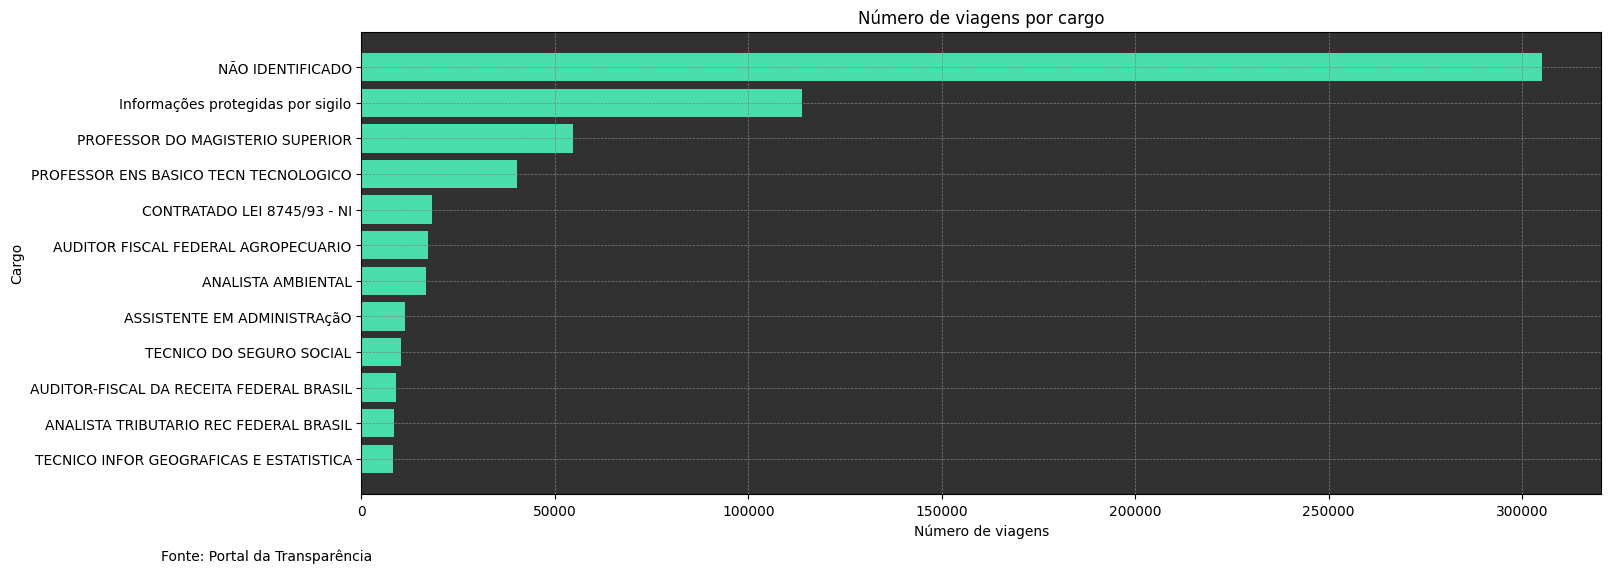

In [27]:
import matplotlib.pyplot as plt

# Criando a figura
fig, ax = plt.subplots(figsize=(16, 6))

# Plotando o gráfico
ax.barh(df_final['Cargo'], df_final['n_viagens'], color='#49deac')
ax.invert_yaxis()
ax.set_facecolor('#313131')

# Ajustando o gráfico
ax.set_xlabel('Número de viagens')
ax.set_ylabel('Cargo')
ax.set_title('Número de viagens por cargo')
plt.figtext(0, 0, 'Fonte: Portal da Transparência')
plt.grid(color='gray', linestyle='--', linewidth=0.5)

# Salvando gráfico
plt.savefig(data_graph_output, bbox_inches='tight')